# Build Simple NN Models

<a href="https://colab.research.google.com/github/HassanAlgoz/dl/blob/main/modules/M2/02-feedforward-models/02-feedforward-models.ipynb" target="_blank">
  <img src="https://raw.githubusercontent.com/HassanAlgoz/dl/main/assets/Open%20in%20Colab-F9AB00.svg" alt="Open in Colab" height="50"/>
</a>


In [1]:
# --- Setup: Clone repo & cd into correct folder (for lab setup convenience) ---
import os
import subprocess

repo_url = "https://github.com/HassanAlgoz/dl.git"
lab_folder = "dl/modules/M2/02-feedforward-models"

# Only clone if the folder doesn't exist
if not os.path.exists(lab_folder):
    subprocess.run(["git", "clone", repo_url])

# Change working directory to the lab folder
os.chdir(lab_folder)


### About
Dive into the Pytorch ecosystem: how to load data, set up architecture, train and predict using neural nets.

### Learning Objectives
1. Implement regression and classification models using PyTorch.
2. Understand training loops and model evaluation.
3. Explore how to visualize training results.

### Notebook Guide
1. Linear Regression Model
2. Binary Classification Model
3. Summary of Notebook

**Note:** this lesson is designed to be run using Google Colab

### 1. Linear Regression Model

**Task:** Build a simple linear regression model to predict outputs based on input features.

In [ ]:
# %pip install -qqq torch

In [2]:
import torch # main pytorch library
import torch.nn as nn # neural network building blocks (layers, activations, loss functions)
import torch.optim as optim # optimization algorithms (gradient descent)

In [9]:
# Generate dummy data
torch.manual_seed(42) # random seed for reproducibility
x = torch.randn(100, 1) # 100 random inputs
y = 3 * x + 2 + torch.randn(100, 1) * 0.5 # y = 3x + 2 + small noise


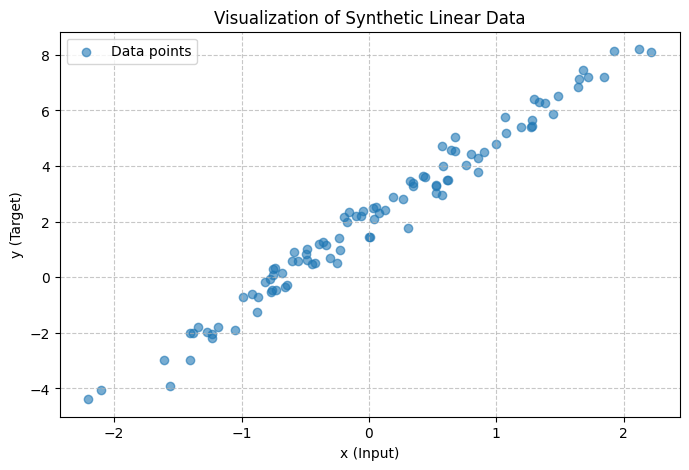

In [10]:
import matplotlib.pyplot as plt

# Plotting the dummy data generated earlier
plt.figure(figsize=(8, 5))
plt.scatter(x.numpy(), y.numpy(), alpha=0.6, label="Data points")
plt.xlabel("x (Input)")
plt.ylabel("y (Target)")
plt.title("Visualization of Synthetic Linear Data")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [11]:
# Define the linear regression model
model = nn.Linear(1, 1)

`nn.Linear(1, 1)` creates a learnable linear layer with 1 input feature and 1 output feature.

Internally, PyTorch creates a weighted matrix W with dimensions (1, 1) and a bias shaped (1)

The weight and bias terms start randomly and will be learned with gradient descent!

In [12]:
print(f"Weight: {model.weight.item()}")
print(f"Bias: {model.bias.item()}")

Weight: 0.48010575771331787
Bias: 0.8415044546127319


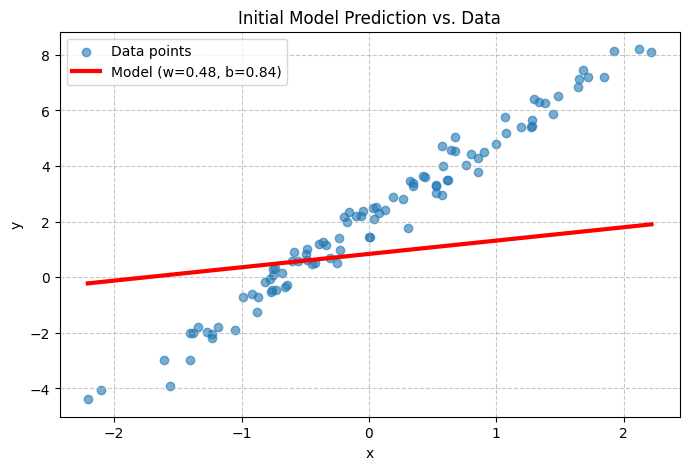

In [15]:
import matplotlib.pyplot as plt
import torch

# Define the parameters
w = 0.48
b = 0.84

# Calculate the line values: y = wx + b
# We use the range of x to draw the line
x_line = torch.linspace(x.min(), x.max(), 100)
y_line = w * x_line + b

# Plotting
plt.figure(figsize=(8, 5))
plt.scatter(x.numpy(), y.numpy(), alpha=0.6, label="Data points")
plt.plot(x_line.numpy(), y_line.numpy(), color='red', linewidth=3, label=f"Model (w={w}, b={b})")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Initial Model Prediction vs. Data")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [13]:
# Loss function and optimizer
criterion = nn.MSELoss()
optimizer = optim.SGD(model.parameters(), lr=0.01)

We're defining our loss function as Mean Squared Error

The optimizer is defining how we're going to update the weights. SGD is Stochastic Gradient Descent, with a learning rate of 0.01

The `model.parameters()` gives the optimizer access to the model's weight and bias to update them.

In [14]:
# Training loop
epochs = 100
for epoch in range(epochs):
    optimizer.zero_grad()
    predictions = model(x)
    loss = criterion(predictions, y)
    loss.backward()
    optimizer.step()

    if epoch % 10 == 0:
        print(f"Epoch {epoch}: Loss = {loss.item()}")

print("Trained Model Parameters:")
print("Weight:", model.weight.item())
print("Bias:", model.bias.item())

Epoch 0: Loss = 8.101666450500488
Epoch 10: Loss = 5.429515838623047
Epoch 20: Loss = 3.66190767288208
Epoch 30: Loss = 2.4921886920928955
Epoch 40: Loss = 1.7178114652633667
Epoch 50: Loss = 1.2049442529678345
Epoch 60: Loss = 0.8651283383369446
Epoch 70: Loss = 0.639873743057251
Epoch 80: Loss = 0.49049076437950134
Epoch 90: Loss = 0.3913775682449341
Trained Model Parameters:
Weight: 2.664585828781128
Bias: 1.9030166864395142


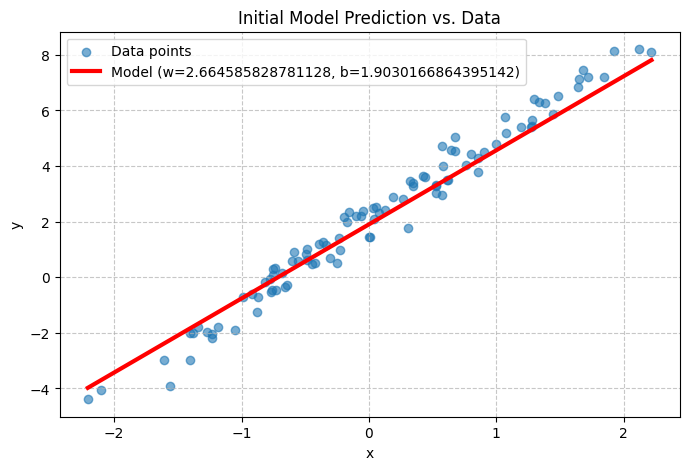

In [18]:
w = model.weight.item()
b = model.bias.item()

# Calculate the line values: y = wx + b
# We use the range of x to draw the line
x_line = torch.linspace(x.min(), x.max(), 100)
y_line = w * x_line + b

# Plotting
plt.figure(figsize=(8, 5))
plt.scatter(x.numpy(), y.numpy(), alpha=0.6, label="Data points")
plt.plot(x_line.numpy(), y_line.numpy(), color='red', linewidth=3, label=f"Model (w={w}, b={b})")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Initial Model Prediction vs. Data")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

Remember that an epoch is one complete pass of the **entire** training data.

The `zero_grad()` resets gradients so they don't pile up across iterations of training.

`predictions = model(x)` is a forward pass through our network and gets our predictions.

We then calculate the MSE with
`loss = criterion(predictions, y)`

and then do backpropagation with
`loss.backward()`

and lastly update our gradient descent with
`optimizer.step()`

**Exercise 1: Experiment with Learning Rates**
Modify the above code to try different learning rates (`0.1`, `0.01`, and `0.001`). Observe how the loss decreases for each case.

**Solution:**

**Exercise 1: Modify Linear Regression Model**
1. Add an additional input feature to the dummy data (e.g., `x2`).
2. Update the linear regression model to handle two input features.
3. Train the updated model and print the new weights and bias.

**Solution:**

In [19]:
# Solution for Exercise 1
# Generate dummy data with two features
x = torch.cat([torch.randn(100, 1), torch.randn(100, 1)], dim=1)
y = 3 * x[:, 0:1] + 2 * x[:, 1:2] + 2 + torch.randn(100, 1) * 0.1

# Update the linear regression model
model = nn.Linear(2, 1)

# Loss function and optimizer
criterion = nn.MSELoss()
optimizer = optim.SGD(model.parameters(), lr=0.01)

# Train the updated model
for epoch in range(100):
    optimizer.zero_grad()
    predictions = model(x)
    loss = criterion(predictions, y)
    loss.backward()
    optimizer.step()

print("Updated Model Parameters:")
print("Weights:", model.weight)
print("Bias:", model.bias)

Updated Model Parameters:
Weights: Parameter containing:
tensor([[2.4819, 1.8496]], requires_grad=True)
Bias: Parameter containing:
tensor([1.9149], requires_grad=True)


### Experiment with different learning rates


In [20]:
# Experiment with different learning rates
# Regenerate single-feature data so this cell does not depend on the 2-feature exercise above
torch.manual_seed(42)
x = torch.randn(100, 1)
y = 3 * x + 2 + torch.randn(100, 1) * 0.1
criterion = nn.MSELoss()

learning_rates = [0.1, 0.01, 0.001]
for lr in learning_rates:
    model = nn.Linear(1, 1)
    optimizer = optim.SGD(model.parameters(), lr=lr)

    print(f"Training with Learning Rate = {lr}")
    for epoch in range(20):
        optimizer.zero_grad()
        predictions = model(x)
        loss = criterion(predictions, y)
        loss.backward()
        optimizer.step()

        if epoch % 5 == 0:
            print(f"Epoch {epoch}: Loss = {loss.item()}")
    print("-" * 30)

Training with Learning Rate = 0.1
Epoch 0: Loss = 7.852996826171875
Epoch 5: Loss = 0.8135984539985657
Epoch 10: Loss = 0.09207548201084137
Epoch 15: Loss = 0.01680035889148712
------------------------------
Training with Learning Rate = 0.01
Epoch 0: Loss = 9.523448944091797
Epoch 5: Loss = 7.726961612701416
Epoch 10: Loss = 6.269941806793213
Epoch 15: Loss = 5.088192939758301
------------------------------
Training with Learning Rate = 0.001
Epoch 0: Loss = 17.407411575317383
Epoch 5: Loss = 17.048200607299805
Epoch 10: Loss = 16.696407318115234
Epoch 15: Loss = 16.351877212524414
------------------------------


### 2. Binary Classification Model

**Task:** Build a binary classification model using a fully connected neural network.

In [26]:
# Generate dummy data for classification
torch.manual_seed(42)
x = torch.randn(100, 2)
y = (x[:, 0] + x[:, 1] > 0).long()

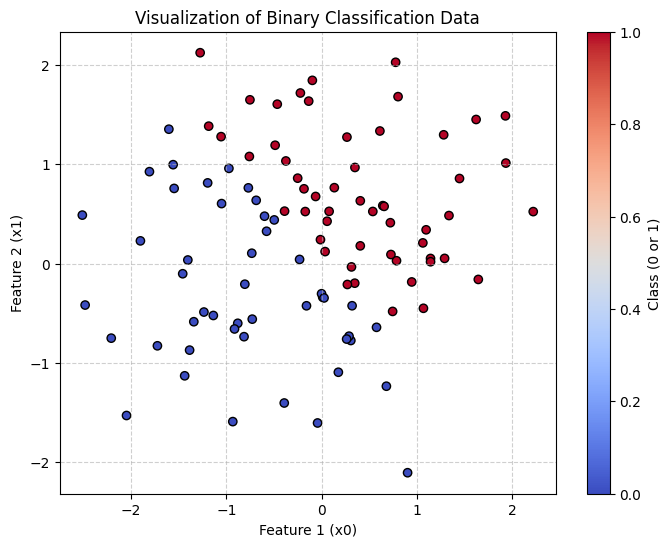

In [30]:
import matplotlib.pyplot as plt

# Plotting the classification data points
plt.figure(figsize=(8, 6))
# x is 100x2, y is 100
plt.scatter(x[:, 0].numpy(), x[:, 1].numpy(), c=y.numpy(), cmap='coolwarm', edgecolors='k')
plt.xlabel('Feature 1 (x0)')
plt.ylabel('Feature 2 (x1)')
plt.title('Visualization of Binary Classification Data')
plt.grid(True, linestyle='--', alpha=0.6)
plt.colorbar(label='Class (0 or 1)')
plt.show()

`x` now contains 100 samples with 2 features.

The `.long()` on the end of `y` ensures our target variable is the typical `0` and `1` for a binary classification problem.

In [28]:
x[:5]

tensor([[ 1.9269,  1.4873],
        [ 0.9007, -2.1055],
        [ 0.6784, -1.2345],
        [-0.0431, -1.6047],
        [-0.7521,  1.6487]])

In [29]:
y[:5]

tensor([1, 0, 0, 0, 1])

In [34]:
# Define the classification model
model = nn.Sequential(
    nn.Linear(2, 4),
    nn.ReLU(),
    nn.Linear(4, 2)
)

Unsurprisingly since we're now doing classification, our model's architecture has changed. We now have multiple layers in our network.

We specify a linear layer with 2 features and 4 neurons.

We use ReLU for non-linear activation function and allows the model to learn a non-linear decision boundary between the classes.

Then we get to our output layer, which has 2 neurons, 1 per class in the output.

In [35]:
# Loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

Because our target variable is discrete and binary, we need to use CrossEntropy as our loss function.

We can still use Stochastic Gradient Descent as our optimizer.

In [36]:
# Training loop
epochs = 100
for epoch in range(epochs):
    optimizer.zero_grad()
    predictions = model(x)
    loss = criterion(predictions, y)
    loss.backward()
    optimizer.step()

    if epoch % 10 == 0:
        print(f"Epoch {epoch}: Loss = {loss.item()}")

print("Trained Model:")
print(model)

Epoch 0: Loss = 0.671501100063324
Epoch 10: Loss = 0.5593050122261047
Epoch 20: Loss = 0.4495287239551544
Epoch 30: Loss = 0.3505566120147705
Epoch 40: Loss = 0.27179384231567383
Epoch 50: Loss = 0.21682193875312805
Epoch 60: Loss = 0.17970462143421173
Epoch 70: Loss = 0.15400609374046326
Epoch 80: Loss = 0.13542486727237701
Epoch 90: Loss = 0.12136966735124588
Trained Model:
Sequential(
  (0): Linear(in_features=2, out_features=4, bias=True)
  (1): ReLU()
  (2): Linear(in_features=4, out_features=2, bias=True)
)


Similar process for training the model.

We specify the number of epochs. Each epoch has the gradients zeroed out, makes predictions, calculates the value of the loss function, does backpropagation, and then does a gradient descent update step.

### Visualize Decision Boundaries
Write a script to visualize the decision boundaries of the classification model.

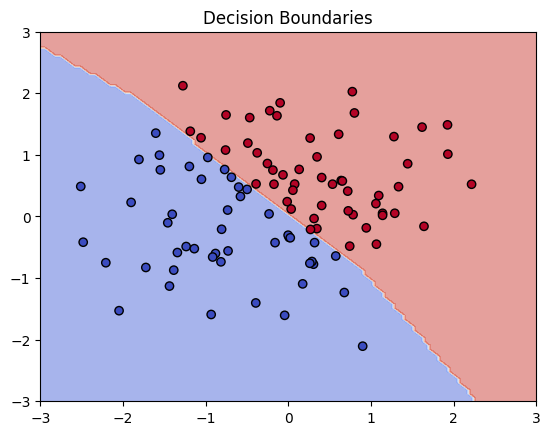

In [37]:
import matplotlib.pyplot as plt
import numpy as np

# Generate a grid of points
xx, yy = np.meshgrid(
    np.linspace(-3, 3, 100),
    np.linspace(-3, 3, 100)
  )

grid = torch.tensor(
    np.c_[xx.ravel(), yy.ravel()],
    dtype=torch.float32
  )

# Predict on the grid
with torch.no_grad():
    logits = model(grid)
    predictions = logits.argmax(dim=1).numpy()

# Plot the decision boundary
plt.contourf(
    xx, yy, predictions.reshape(xx.shape),
    alpha=0.5,
    cmap="coolwarm"
  )
plt.scatter(
    x[:, 0], x[:, 1],
    c=y,
    edgecolor='k',
    cmap="coolwarm"
  )

plt.title("Decision Boundaries")
plt.show()

**Exercise 2: Binary Classification with Custom Features**
1. Create a new binary classification dataset where the labels depend on the sum of two input features.
2. Train a classification model using ReLU activation and print the training loss every 10 epochs.

**Solution:**

In [ ]:
# Solution for Exercise 2
# Generate custom binary classification data
torch.manual_seed(42)
x = torch.randn(100, 2)
y = (x[:, 0] + 2 * x[:, 1] > 1).long()

# Define the classification model
model = nn.Sequential(
    nn.Linear(2, 4),
    nn.ReLU(),
    nn.Linear(4, 2)
)

# Loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.01)

# Train the model
for epoch in range(100):
    optimizer.zero_grad()
    predictions = model(x)
    loss = criterion(predictions, y)
    loss.backward()
    optimizer.step()

    if epoch % 10 == 0:
        print(f"Epoch {epoch}: Loss = {loss.item()}")


**Exercise 3: Modify Decision Boundaries**
1. Train the classification model with more hidden neurons and different activation functions.
2. Visualize the new decision boundaries and compare them with the original model.

**Solution:**

In [ ]:
# Solution for Exercise 3
# Compare original (ReLU, 4 hidden) vs modified (Tanh, 8 hidden) decision boundaries
torch.manual_seed(42)
x = torch.randn(100, 2)
y = (x[:, 0] + x[:, 1] > 0).long()
criterion = nn.CrossEntropyLoss()

def train_classifier(model, epochs=100):
    optimizer = optim.SGD(model.parameters(), lr=0.01)
    for epoch in range(epochs):
        optimizer.zero_grad()
        predictions = model(x)
        loss = criterion(predictions, y)
        loss.backward()
        optimizer.step()
    return model

original_model = train_classifier(nn.Sequential(
    nn.Linear(2, 4),
    nn.ReLU(),
    nn.Linear(4, 2)
))

modified_model = train_classifier(nn.Sequential(
    nn.Linear(2, 8),
    nn.Tanh(),
    nn.Linear(8, 2)
))

# Visualize the decision boundaries side by side
xx, yy = np.meshgrid(np.linspace(-3, 3, 100), np.linspace(-3, 3, 100))
grid = torch.tensor(np.c_[xx.ravel(), yy.ravel()], dtype=torch.float32)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, clf, title in [
    (axes[0], original_model, "Original (ReLU, 4 hidden)"),
    (axes[1], modified_model, "Modified (Tanh, 8 hidden)"),
]:
    with torch.no_grad():
        preds = clf(grid).argmax(dim=1).numpy()
    ax.contourf(xx, yy, preds.reshape(xx.shape), alpha=0.5, cmap="coolwarm")
    ax.scatter(x[:, 0], x[:, 1], c=y, edgecolor="k", cmap="coolwarm")
    ax.set_title(title)

plt.tight_layout()
plt.show()


### Summary of Notebook

By the end of this notebook, you should be able to:
1. Build and train a regression model using PyTorch.
2. Build and train a binary classification model.
3. Visualize decision boundaries for classification models.